In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, 
                                            width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, 
                                                                                                             width=i+1)+' sigma'

In [4]:
def f(t, nmax, T):
    res = 0.0
    for n in range(0,nmax):
        res += (n+1.0) * np.exp( -(n+1.0)*t )
        res += (n+1.0) * np.exp( -(n+1.0)*(T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(2*T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+2*T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(3*T-t) )
    return res/(4.0*np.pi)

In [5]:
masses_=[]

In [6]:
T=16
Nt=24 # 240

In [7]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

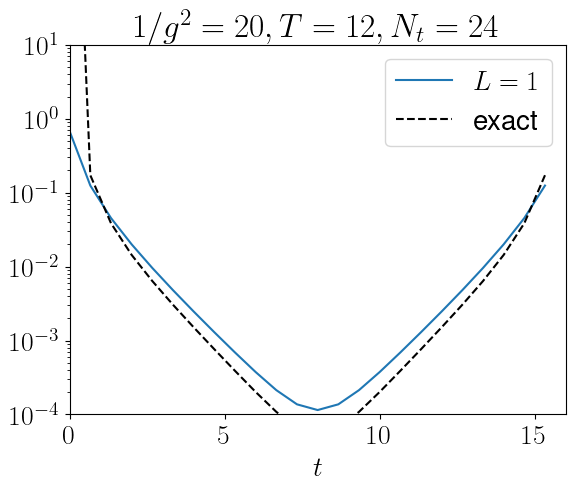

In [8]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [9]:
Nt/T

1.5

In [10]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [11]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [12]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

Text(0, 0.5, '$\\Delta_{\\rm eff}(t)$')

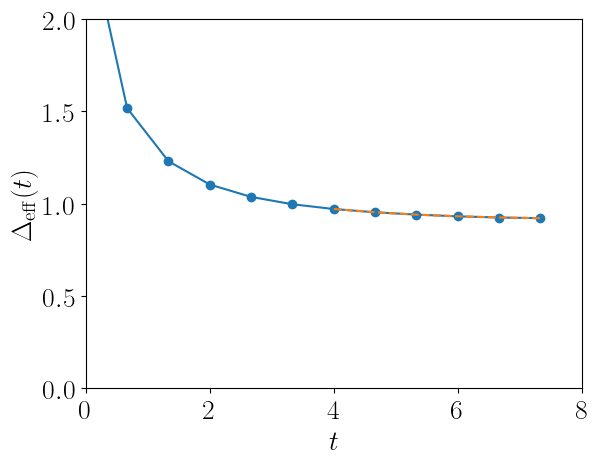

In [13]:
# plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[:fitM], yy[:fitM], marker='o' )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]), 
        ls='dashed')

plt.xlim(0,T/2)
plt.ylim(0,2)

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}(t)$")
# plt.title("$T=12, L_t="+str(Nt)+", M = 1$")

In [14]:
masses_.append([1, Nt, opt[0][0]])

In [15]:
Nt=48 # 240

In [16]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

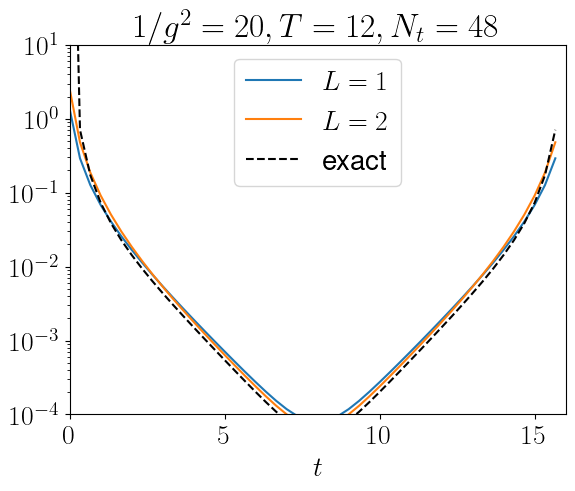

In [17]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [18]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
# fitM = int(8.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [19]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [20]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

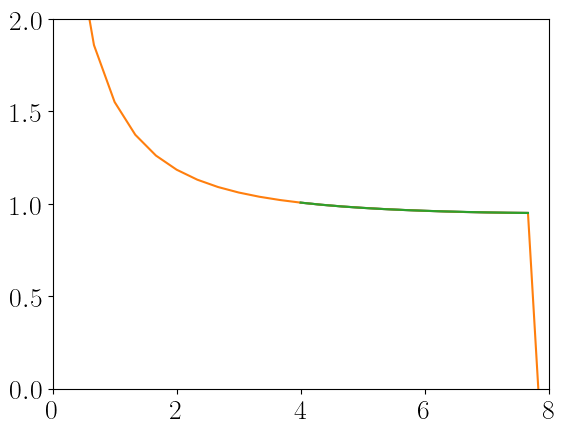

In [21]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [22]:
masses_.append([1, Nt, opt[0][0]])

In [23]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [24]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

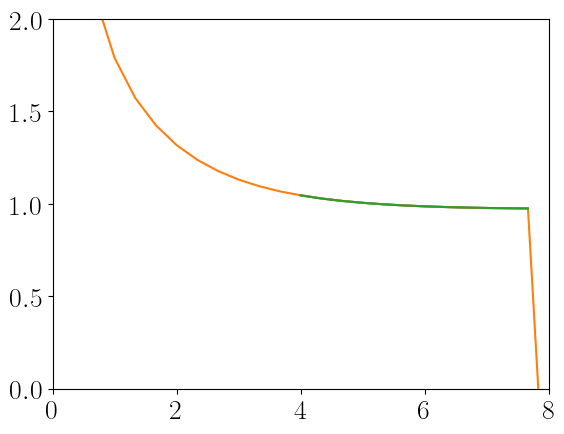

In [25]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [26]:
masses_.append([2, Nt, opt[0][0]])

In [27]:
Nt=64 # 240

In [28]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

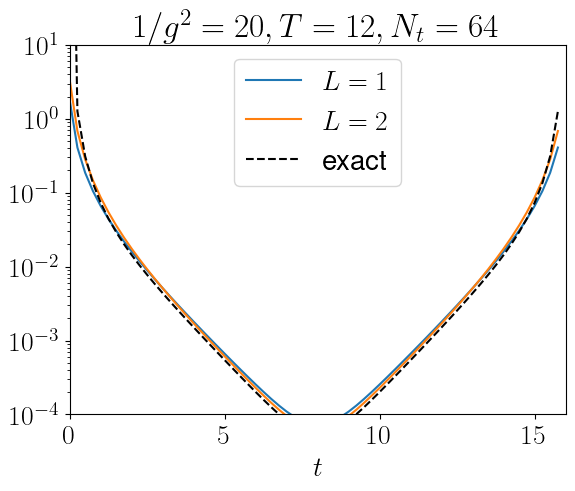

In [29]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [30]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [31]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [32]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

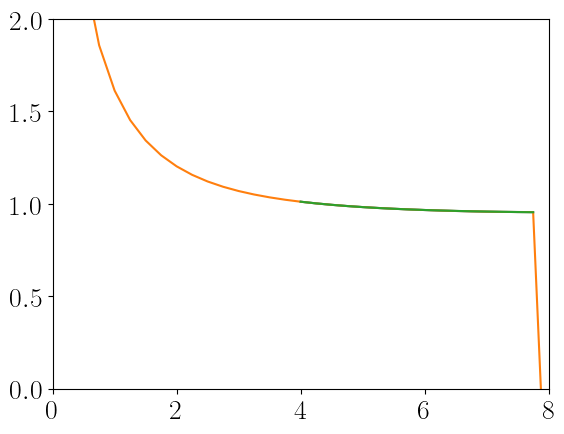

In [33]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [34]:
masses_.append([1, Nt, opt[0][0]])

In [35]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [36]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

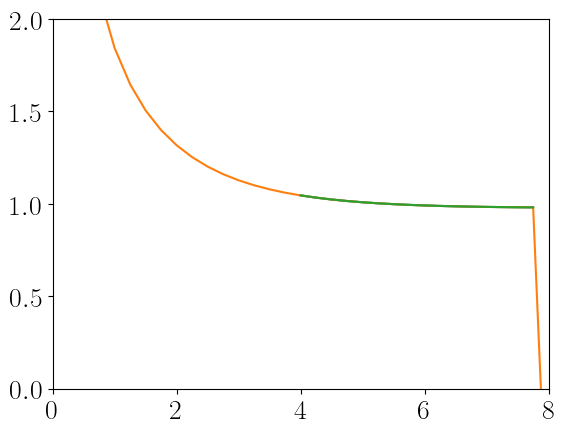

In [37]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [38]:
masses_.append([2, Nt, opt[0][0]])

In [39]:
Nt=96 # 240

In [40]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

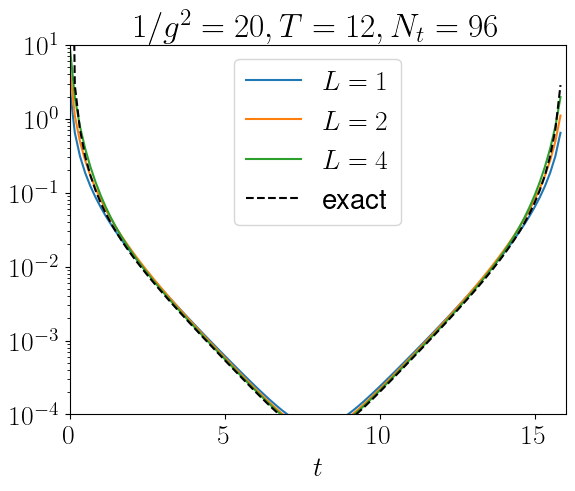

In [41]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [42]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [43]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [44]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

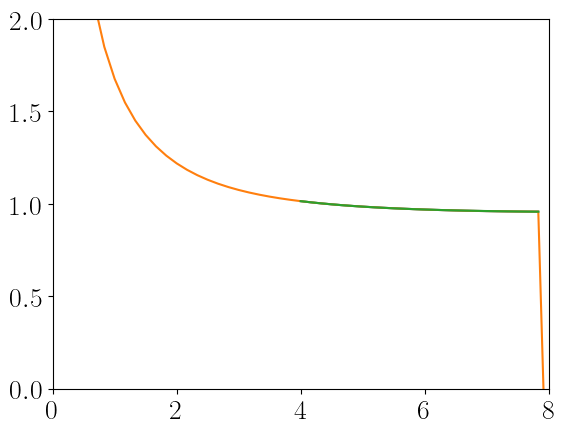

In [45]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [46]:
masses_.append([1, Nt, opt[0][0]])

In [47]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [48]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

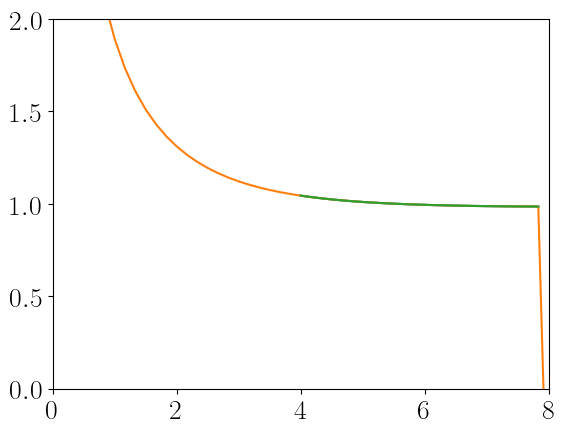

In [49]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [50]:
masses_.append([2, Nt, opt[0][0]])

In [51]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [52]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

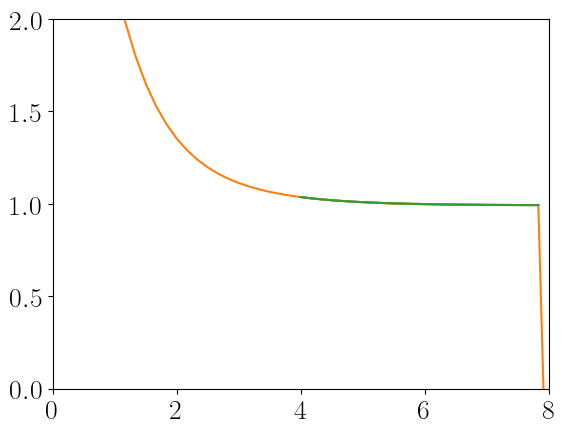

In [53]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [54]:
xx96_4 = xx
yy96_4 = yy
opt96_4 = opt

fitm96 = fitm
fitM96 = fitM

In [55]:
masses_.append([4, Nt, opt[0][0]])

In [56]:
T=16

In [57]:
Nt=120 # 240

In [58]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
# l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

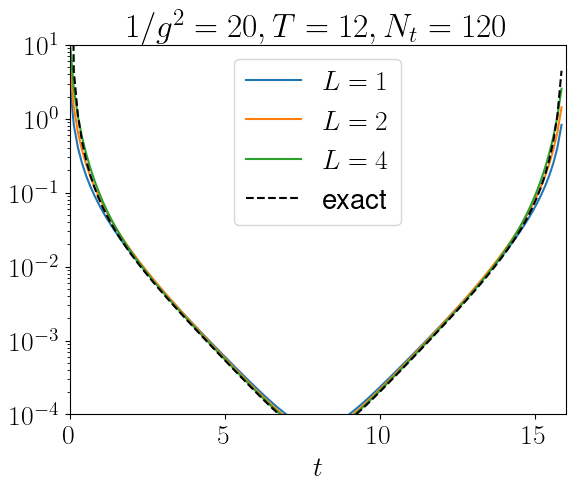

In [59]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [60]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [61]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [62]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

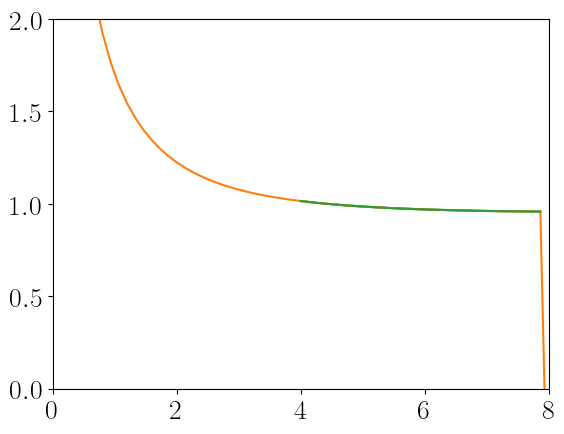

In [63]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [64]:
xx1 = xx
yy1 = yy
opt1 = opt

In [65]:
masses_.append([1, Nt, opt[0][0]])

In [66]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [67]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

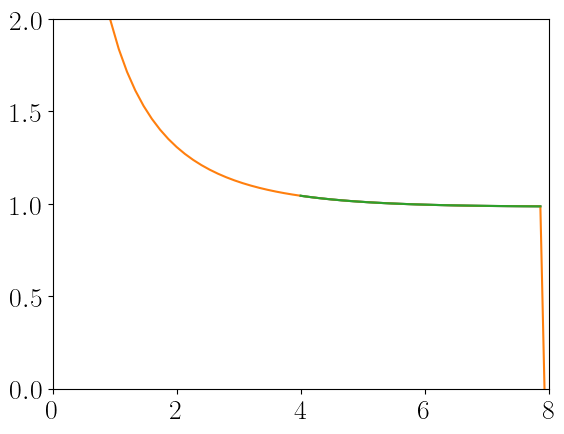

In [68]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [69]:
xx2= xx
yy2 = yy
opt2 = opt

In [70]:
masses_.append([2, Nt, opt[0][0]])

In [71]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [72]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

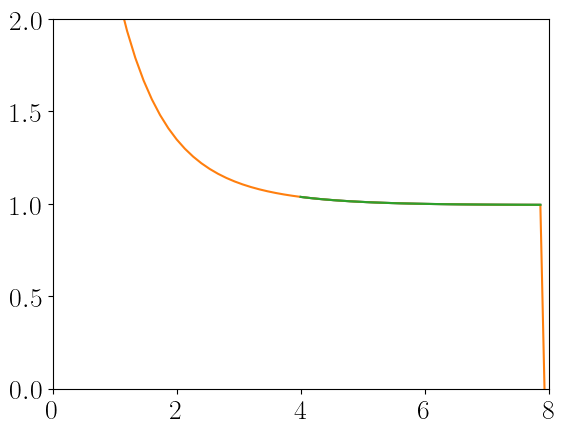

In [73]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [74]:
xx4 = xx
yy4 = yy
opt4 = opt

fitm120 = fitm
fitM120 = fitM

In [75]:
masses_.append([4, Nt, opt[0][0]])

In [76]:
Nt=144 # 240

In [77]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

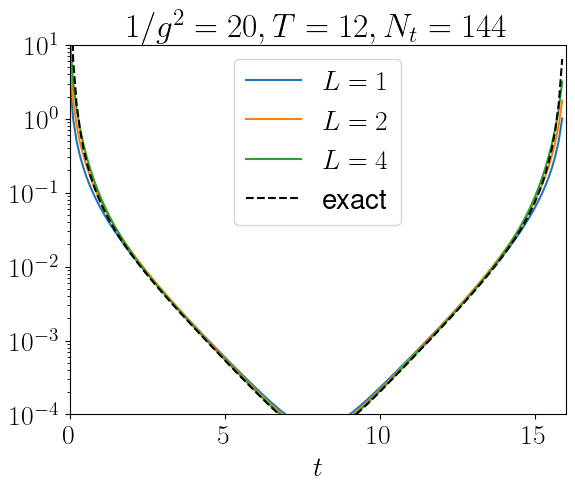

In [78]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [79]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [80]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [81]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

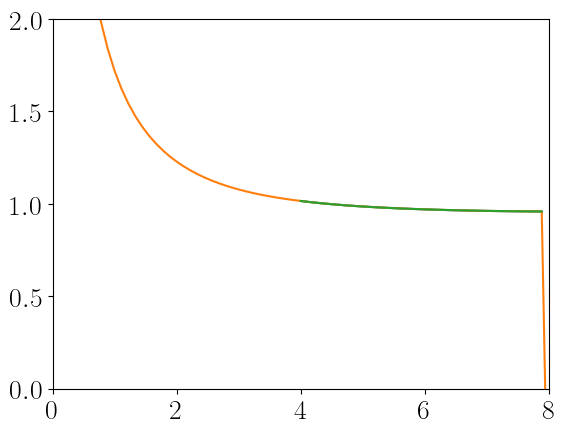

In [82]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [83]:
xx1 = xx
yy1 = yy
opt1 = opt

In [84]:
masses_.append([1, Nt, opt[0][0]])

In [85]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [86]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

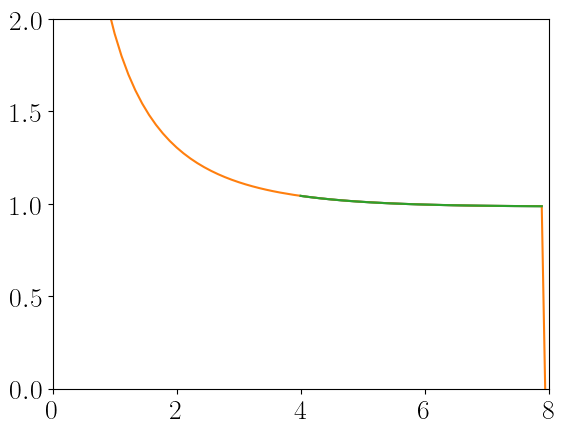

In [87]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [88]:
xx2 = xx
yy2 = yy
opt2 = opt

In [89]:
masses_.append([2, Nt, opt[0][0]])

In [90]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [91]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

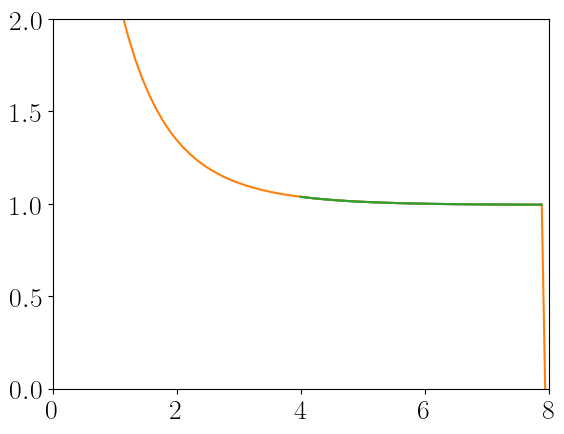

In [92]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [93]:
xx4 = xx
yy4 = yy
opt4 = opt

In [94]:
masses_.append([4, Nt, opt[0][0]])

In [95]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [96]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

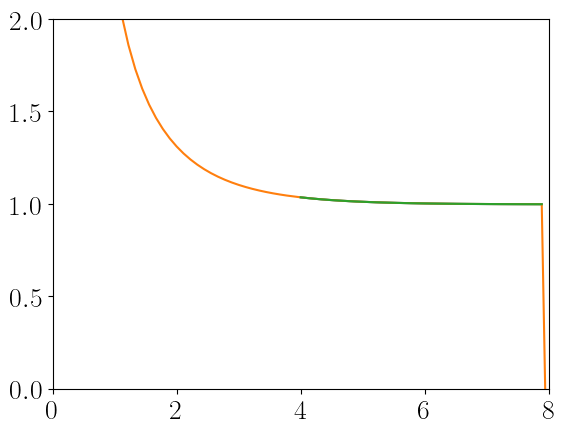

In [97]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [98]:
xx8 = xx
yy8 = yy
opt8 = opt

In [99]:
masses_.append([8, Nt, opt[0][0]])

In [100]:
cs_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

In [165]:
# plt.plot( xx1[:fitM], yy1[:fitM], marker='x', label='$L=1$', c=cs_default[0] )
# plt.plot( xx1[fitm:fitM], fitter(xx1[fitm:fitM], opt1[0][0], opt1[0][1], opt1[0][2]), 
#         ls='dashed', c="#1f2db4", lw=3)


# plt.plot( xx2[:fitM], yy2[:fitM], marker='.', label='$L=2$', c=cs_default[1] )
# plt.plot( xx2[fitm:fitM], fitter(xx2[fitm:fitM], opt2[0][0], opt2[0][1], opt2[0][2]), 
#         ls='dashed', c="#ff7f0e", lw=3)


# plt.plot( xx4[:fitM], yy4[:fitM], marker='+', label='$L=4$', c=cs_default[2] )
# plt.plot( xx4[fitm:fitM], fitter(xx4[fitm:fitM], opt4[0][0], opt4[0][1], opt4[0][2]), 
#         ls='dashed', c="#2ca02c", lw=3)


# plt.plot( xx8[:fitM], yy8[:fitM], marker='d', markersize=3, label='$L=8$', c=cs_default[3] )
# plt.plot( xx8[fitm:fitM], fitter(xx8[fitm:fitM], opt8[0][0], opt8[0][1], opt8[0][2]), 
#         ls='dashed', c="#d62728", lw=3)


# # plt.plot( xx96_4[:fitM96], yy96_4[:fitM96], marker='.' )
# # plt.plot( xx144_4[:fitM144], yy144_4[:fitM144], marker='.' )


# plt.xlim(0,T/2)
# plt.ylim(0.8,2)

# plt.legend()

# plt.title("$L_t=144$")

# plt.xlabel("$t$")
# plt.ylabel("$\\Delta_{\\rm eff}(t)$")
# # plt.title("$T=12, L_t="+str(Nt)+", M = 1$")

# plt.savefig("delta_eff_Lt144.pdf", bbox_inches="tight")

In [166]:
# slices=[1,3,5,8,11,15]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=1$", marker='x' )

# slices=[2,4,6,9,12,16]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=2$", marker='.' )

# slices=[7,10,13,17]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, yyy-lim, label="$L=4$", marker='+' )

# slices=[14,18]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, yyy-lim, label="$L=8$", marker='d' )

# plt.xlim(0,0.08)
# plt.legend()

# plt.xlabel("$a_t^2$")
# plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

# plt.savefig("at_scaling_fermion.pdf", bbox_inches="tight")

In [239]:
Nt=168 # 240

In [240]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

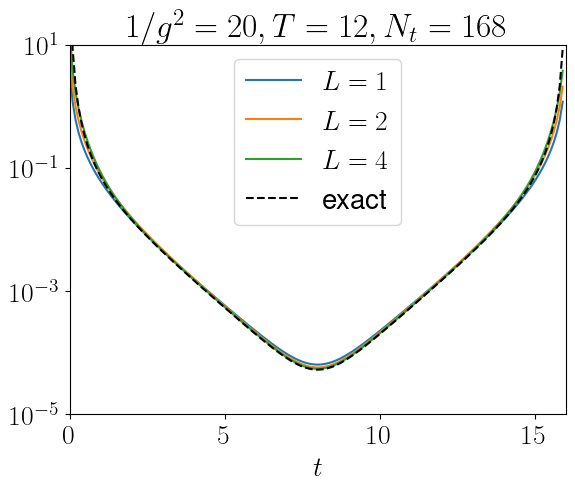

In [241]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-5, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [242]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [243]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [244]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

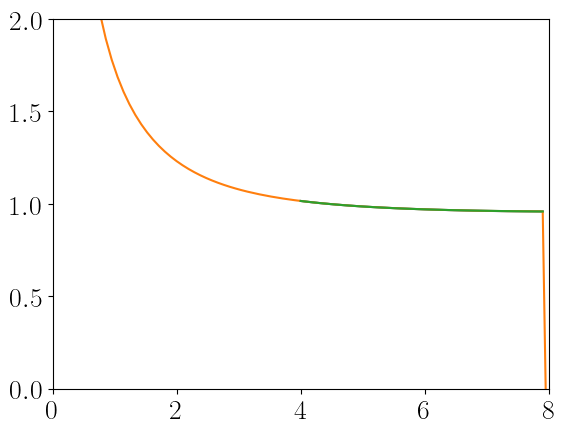

In [245]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [246]:
masses_.append([1, Nt, opt[0][0]])

In [247]:
xx1 = xx
yy1 = yy
opt1 = opt

In [248]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [249]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

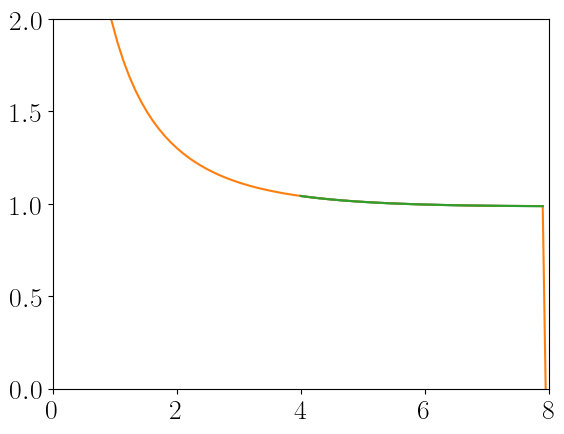

In [250]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [251]:
masses_.append([2, Nt, opt[0][0]])

In [252]:
xx2 = xx
yy2 = yy
opt2 = opt

In [253]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [254]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

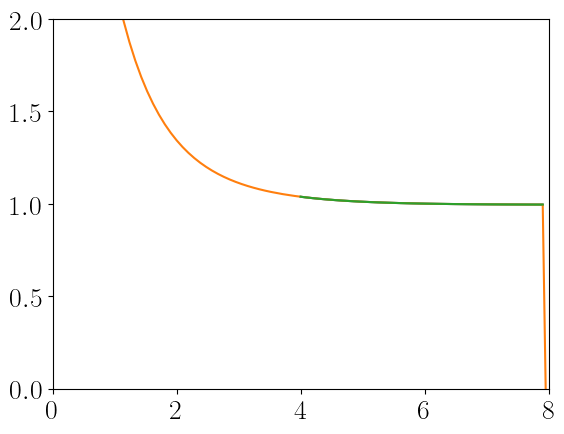

In [255]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [256]:
masses_.append([4, Nt, opt[0][0]])

In [257]:
xx4 = xx
yy4 = yy
opt4 = opt

In [258]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [259]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

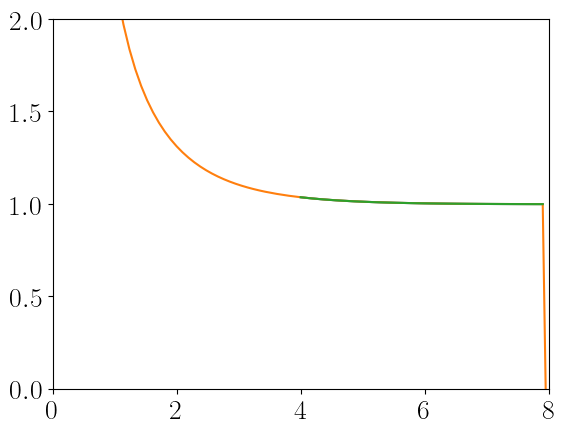

In [260]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [261]:
masses_.append([8, Nt, opt[0][0]])

In [262]:
xx8 = xx
yy8 = yy
opt8 = opt

In [263]:
fitM

84

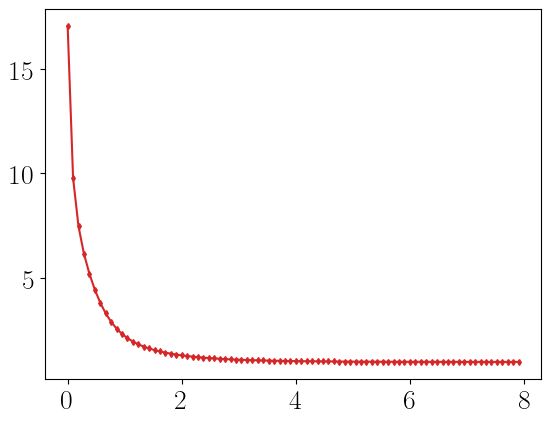

In [264]:
plt.plot( xx8[:fitM], yy8[:fitM], marker='d', markersize=3, label='$L=8$', c=cs_default[3] )
# plt.plot( xx8[fitm:fitM], fitter(xx8[fitm:fitM], opt8[0][0], opt8[0][1], opt8[0][2]), 
#         ls='dashed', c="#d62728", lw=3)


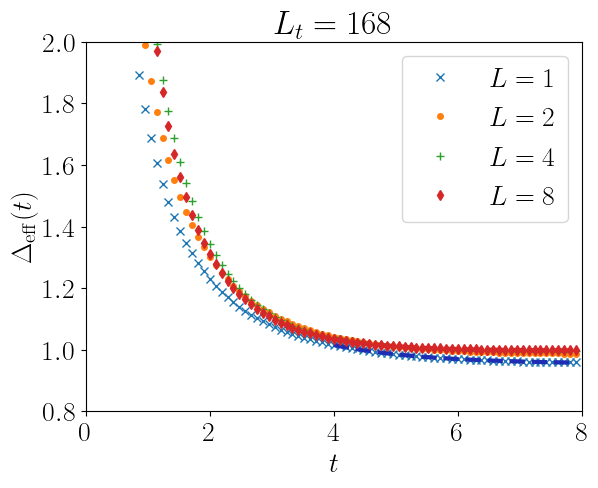

In [275]:
plt.plot( xx1[:fitM], yy1[:fitM], marker='x', markersize=6,label='$L=1$', c=cs_default[0], ls='none' )
plt.plot( xx1[fitm:fitM], fitter(xx1[fitm:fitM], opt1[0][0], opt1[0][1], opt1[0][2]), 
        ls='dashed', c="#1f2db4", lw=3)


plt.plot( xx2[:fitM], yy2[:fitM], marker='.', markersize=8,label='$L=2$', c=cs_default[1], ls='none' )
plt.plot( xx2[fitm:fitM], fitter(xx2[fitm:fitM], opt2[0][0], opt2[0][1], opt2[0][2]), 
        ls='dashed', c="#ff7f0e", lw=3)


plt.plot( xx4[:fitM], yy4[:fitM], marker='+', markersize=6,label='$L=4$', c=cs_default[2], ls='none' )
plt.plot( xx4[fitm:fitM], fitter(xx4[fitm:fitM], opt4[0][0], opt4[0][1], opt4[0][2]), 
        ls='dashed', c="#2ca02c", lw=3)


plt.plot( xx8[:fitM], yy8[:fitM], marker='d', markersize=5, label='$L=8$', c=cs_default[3], ls='none' )
plt.plot( xx8[fitm:fitM], fitter(xx8[fitm:fitM], opt8[0][0], opt8[0][1], opt8[0][2]), 
        ls='dashed', c="#d62728", lw=3)


# plt.plot( xx96_4[:fitM96], yy96_4[:fitM96], marker='.' )
# plt.plot( xx144_4[:fitM144], yy144_4[:fitM144], marker='.' )


plt.xlim(0,T/2)
plt.ylim(0.8,2)

plt.legend()

plt.title("$L_t=168$")

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}(t)$")
# plt.title("$T=12, L_t="+str(Nt)+", M = 1$")

plt.savefig("delta_eff_Lt168.pdf", bbox_inches="tight")

In [124]:
masses = np.array(masses_)
masses

array([[  1.        ,  24.        ,   0.91104004],
       [  1.        ,  48.        ,   0.94345505],
       [  2.        ,  48.        ,   0.97025346],
       [  1.        ,  64.        ,   0.94853244],
       [  2.        ,  64.        ,   0.9771621 ],
       [  1.        ,  96.        ,   0.95211348],
       [  2.        ,  96.        ,   0.98225957],
       [  4.        ,  96.        ,   0.99212287],
       [  1.        , 120.        ,   0.95310409],
       [  2.        , 120.        ,   0.98375002],
       [  4.        , 120.        ,   0.99370338],
       [  1.        , 144.        ,   0.95362039],
       [  2.        , 144.        ,   0.98456222],
       [  4.        , 144.        ,   0.9945686 ],
       [  8.        , 144.        ,   0.99721095],
       [  1.        , 168.        ,   0.95391786],
       [  2.        , 168.        ,   0.98505203],
       [  4.        , 168.        ,   0.99509253],
       [  8.        , 168.        ,   0.99774372]])

In [125]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [126]:
masses

array([[  1.        ,  24.        ,   0.91104004],
       [  1.        ,  48.        ,   0.94345505],
       [  2.        ,  48.        ,   0.97025346],
       [  1.        ,  64.        ,   0.94853244],
       [  2.        ,  64.        ,   0.9771621 ],
       [  1.        ,  96.        ,   0.95211348],
       [  2.        ,  96.        ,   0.98225957],
       [  4.        ,  96.        ,   0.99212287],
       [  1.        , 120.        ,   0.95310409],
       [  2.        , 120.        ,   0.98375002],
       [  4.        , 120.        ,   0.99370338],
       [  1.        , 144.        ,   0.95362039],
       [  2.        , 144.        ,   0.98456222],
       [  4.        , 144.        ,   0.9945686 ],
       [  8.        , 144.        ,   0.99721095],
       [  1.        , 168.        ,   0.95391786],
       [  2.        , 168.        ,   0.98505203],
       [  4.        , 168.        ,   0.99509253],
       [  8.        , 168.        ,   0.99774372]])

In [127]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [128]:
def fitter( x, c0, cx, ct ):
    return c0 + cx*x[0]**2 + ct*x[1]**2

In [129]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [130]:
opt1

(array([ 0.99806805, -0.03532443, -0.10122957]),
 array([[ 0.12413778, -0.1153731 , -0.07921769],
        [-0.1153731 ,  0.23900293, -0.4496813 ],
        [-0.07921769, -0.4496813 ,  6.3978887 ]]),
 {'fvec': array([-1.26282422e-03,  6.53509073e-05,  4.23094319e-03, -9.11527624e-05,
          2.24318503e-03, -1.57280553e-04,  6.60631946e-04, -3.48236302e-05,
         -1.35593531e-04,  1.82476490e-04, -6.03039670e-04, -1.02008628e-04,
         -7.98399814e-05, -9.18369038e-04, -1.18986105e-03, -6.79096735e-05,
         -2.38084182e-04, -1.11073551e-03, -1.39106513e-03]),
  'nfev': 9,
  'fjac': array([[-4.35889893,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573],
         [-2.54184171, -2.19583197, -0.16114201,  0.23805085, -0.16114201,
           0.23805085, -0.16114201, -0.2

In [131]:
# for errorbar

In [132]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [133]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [134]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [135]:
opt2

(array([ 0.99982451, -0.03863347, -0.145486  ]),
 array([[  0.27004514,  -0.7561276 ,  -1.06648306],
        [ -0.7561276 ,   5.0867075 , -11.06202729],
        [ -1.06648306, -11.06202729, 122.9406817 ]]),
 {'fvec': array([-8.55541410e-05,  7.80422475e-05,  3.21709881e-05,  1.95520408e-04,
         -3.42010275e-06,  6.98687330e-05, -2.53312398e-05, -5.05530080e-06,
         -5.44554000e-05, -3.86186060e-05, -5.24649428e-05, -1.10702644e-04]),
  'nfev': 9,
  'fjac': array([[-3.46410163,  0.28867513,  0.28867513,  0.28867513,  0.28867513,
           0.28867513,  0.28867513,  0.28867513,  0.28867513,  0.28867513,
           0.28867513,  0.28867513],
         [-0.72145172, -0.49438586,  0.22123977, -0.30372003,  0.22123977,
          -0.30372003,  0.22123977, -0.30372003, -0.43947776,  0.22123977,
          -0.30372003, -0.43947776],
         [-0.09496551, -0.04448414,  0.09018871,  0.0361376 ,  0.43690204,
           0.14701621,  0.49713211,  0.20724628,  0.13228008,  0.53344925,
       

In [136]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [137]:
opt3= sp.optimize.curve_fit( fitter, a_s[5:].T, masses[5:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [138]:
opt3

(array([ 0.99935361, -0.03579492, -0.14467065]),
 array([[ 4.84395466e-01, -1.06384034e-01, -2.27964835e+01],
        [-1.06384034e-01,  3.05268571e-01, -2.50573575e+00],
        [-2.27964835e+01, -2.50573575e+00,  1.51103390e+03]]),
 {'fvec': array([-6.55133355e-04,  5.75195256e-04,  1.84816385e-06, -1.99035542e-04,
          5.31450589e-04, -1.31957087e-04,  7.05255916e-05,  5.05110350e-04,
         -2.11310223e-04, -4.51224281e-04,  2.46910771e-04,  4.89152374e-04,
         -2.61390474e-04, -5.10142134e-04]),
  'nfev': 9,
  'fjac': array([[-3.74165739e+00,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01],
         [-1.79168204e+00,  1.82236351e+00,  2.99988139e-01,
          -3.23429296e-01,  1.57572730e-01,  2.99988139e-01,
          -3.23429296e-01,  1.57572730e-01,  2.999

In [139]:
a_s2

array([[0.59094644, 0.33333333],
       [0.59094644, 0.25      ],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [140]:
T/120

0.13333333333333333

In [141]:
### for errorbar

In [142]:
0.99997646 - 0.9999543

2.2159999999993296e-05

In [148]:
opt4_1 = sp.optimize.curve_fit( fitter, a_s2[2:].T, masses2[2:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [149]:
opt4_1

(array([ 0.99996367, -0.03854274, -0.15554381]),
 array([[ 6.90272163e-01, -6.17316884e-01, -3.08388165e+01],
        [-6.17316884e-01,  5.29169946e+00, -2.16005734e+01],
        [-3.08388165e+01, -2.16005734e+01,  2.23537216e+03]]),
 {'fvec': array([-7.63600835e-05,  6.34416327e-05, -1.13730982e-05,  3.83680338e-05,
          2.13507692e-05,  1.80790043e-05, -3.74106666e-05,  4.10065874e-05,
          3.61254681e-06, -6.07147259e-05]),
  'nfev': 9,
  'fjac': array([[-3.16227765,  0.31622777,  0.31622777,  0.31622777,  0.31622777,
           0.31622777,  0.31622777,  0.31622777,  0.31622777,  0.31622777],
         [-0.56944631,  0.44354855, -0.28972228,  0.29540599, -0.28972228,
           0.29540599,  0.44672374, -0.28972228,  0.29540599,  0.44672374],
         [-0.04912885,  0.00428604, -0.02115072, -0.0871281 , -0.2368618 ,
          -0.34395513, -0.37165012, -0.39172258, -0.49881591, -0.5265109 ]]),
  'ipvt': array([1, 2, 3], dtype=int32),
  'qtf': array([ 2.26582062e-09, -2.403026

In [150]:
# main fit

In [151]:
opt4= sp.optimize.curve_fit( fitter, a_s2[4:].T, masses2[4:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [152]:
opt4

(array([ 0.99999754, -0.03865496, -0.15685694]),
 array([[ 1.87050901e+00, -4.86722616e-01, -1.33274214e+02],
        [-4.86722616e-01,  6.49936531e+00, -4.96710533e+01],
        [-1.33274214e+02, -4.96710533e+01,  1.13607048e+04]]),
 {'fvec': array([-4.00368346e-05,  3.88295734e-05, -1.79940356e-07,  2.56735709e-05,
         -2.22841360e-05,  2.37768681e-05,  1.55081036e-05, -4.12872051e-05]),
  'nfev': 9,
  'fjac': array([[-2.82842712e+00,  3.53553391e-01,  3.53553391e-01,
           3.53553391e-01,  3.53553391e-01,  3.53553391e-01,
           3.53553391e-01,  3.53553391e-01],
         [-4.81484763e-01,  3.98973739e-01, -3.31437630e-01,
           3.19062786e-01,  4.87285856e-01, -3.31437630e-01,
           3.19062786e-01,  4.87285856e-01],
         [-3.52858617e-02,  1.74438526e-03,  9.38204179e-03,
           2.17478658e-01,  2.47016548e-01,  4.52367699e-01,
           5.66587526e-01,  5.96125417e-01]]),
  'ipvt': array([1, 2, 3], dtype=int32),
  'qtf': array([ 2.38221988e-09, -3.3

In [154]:
format_print(opt4[0][0], abs(opt4[0][0]-opt4_1[0][0]))

'0.999998(34)'

In [155]:
[3,4,5]

[3, 4, 5]

In [156]:
slices=[1]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]

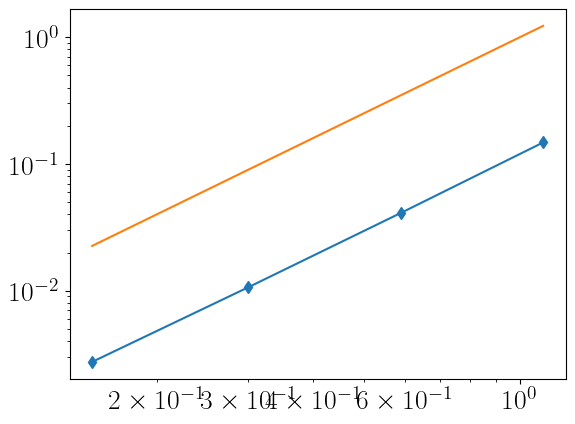

In [157]:
slices=[11,12,13,14]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )*(1-.002)
plt.plot( xxx, yyy-lim, label="$L_t=144$", marker='d' )

plt.plot( xxx, xxx**2 )

plt.xscale("log")
plt.yscale("log")

In [158]:
cs_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

In [159]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [160]:
a_s[slices]

array([[1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111]])

In [161]:
a_s[16:][0][1]

0.09523809523809523

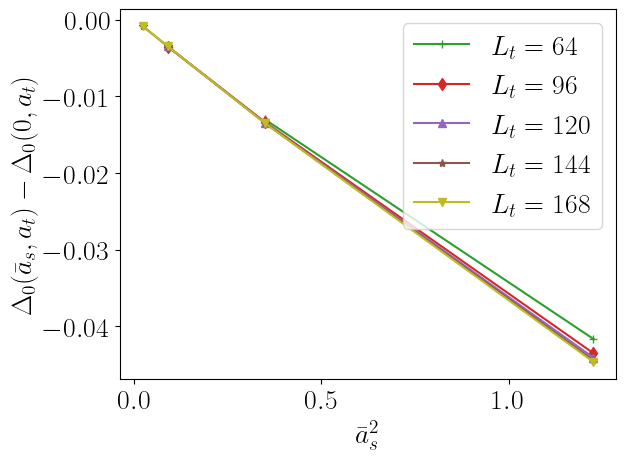

In [162]:
# slices=[1,2]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, yyy-lim, label="$L_t=48$", marker='.' )

slices=[3,4]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=64$", marker='+', c=cs_default[2] )

slices=[5,6,7]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=96$", marker='d', c=cs_default[3] )

slices=[8,9,10]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=120$", marker='^', c=cs_default[4] )

slices=[11,12,13,14]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=144$", marker='*', c=cs_default[5] )

slices=[15,16,17,18]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=168$", marker='v', c=cs_default[8] )

plt.legend()

plt.xlabel("$\\bar{a}_s^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(0, a_t)$")

plt.savefig("ellbar_scaling_fermion.pdf", bbox_inches="tight")

In [163]:
a_s[14:]

array([[0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

[0.94345505 0.94853244 0.95211348 0.95310409 0.95362039 0.95391786]
[0.97025346 0.9771621  0.98225957 0.98375002 0.98456222 0.98505203]
[0.99212287 0.99370338 0.9945686  0.99509253]
[0.99721095 0.99774372]


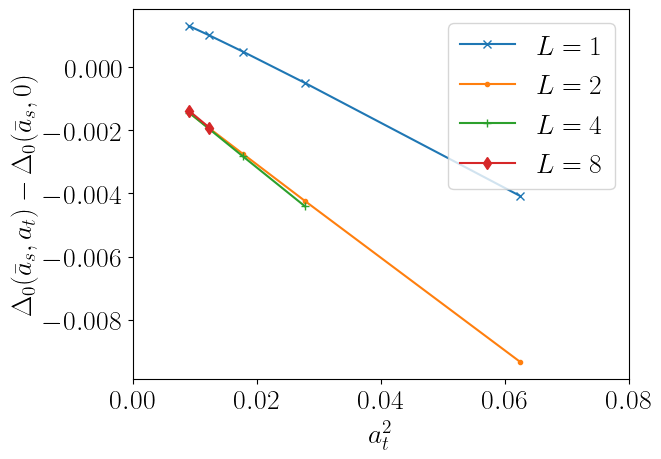

In [164]:
slices=[1,3,5,8,11,15]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=1$", marker='x' )

slices=[2,4,6,9,12,16]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=2$", marker='.' )

slices=[7,10,13,17]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=4$", marker='+' )

slices=[14,18]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=8$", marker='d' )

plt.xlim(0,0.08)
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(\\bar{a}_s, 0)$")

plt.savefig("at_scaling_fermion.pdf", bbox_inches="tight")

In [155]:
print(masses.T[2][slices])

[0.99721095 0.99774372]


In [158]:
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

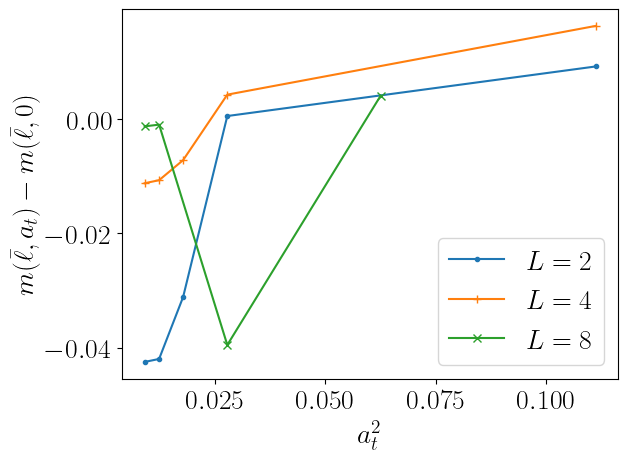

In [159]:
# ibase=0
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='d' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='x' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

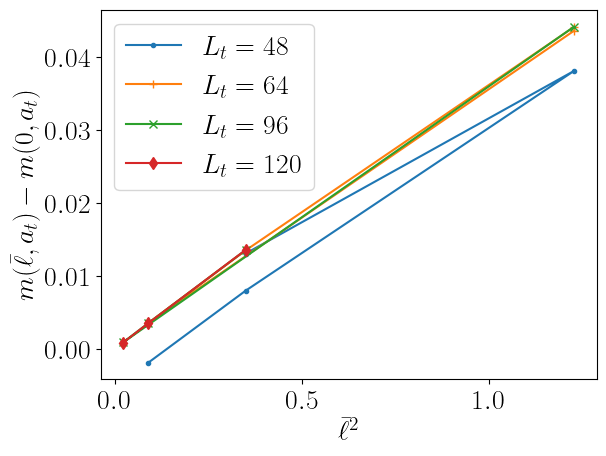

In [160]:
# lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[:4].T[0]**2, lim-masses.T[2][:4], label="$L_t=24$", marker='x' )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, lim-masses.T[2][4:8], label="$L_t=48$", marker='.' )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, lim-masses.T[2][8:12], label="$L_t=64$", marker='+' )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, lim-masses.T[2][12:16], label="$L_t=96$", marker='x' )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, lim-masses.T[2][16:], label="$L_t=120$", marker='d' )

plt.legend()

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

plt.savefig("ellbar_scaling_gauge.pdf", bbox_inches="tight")

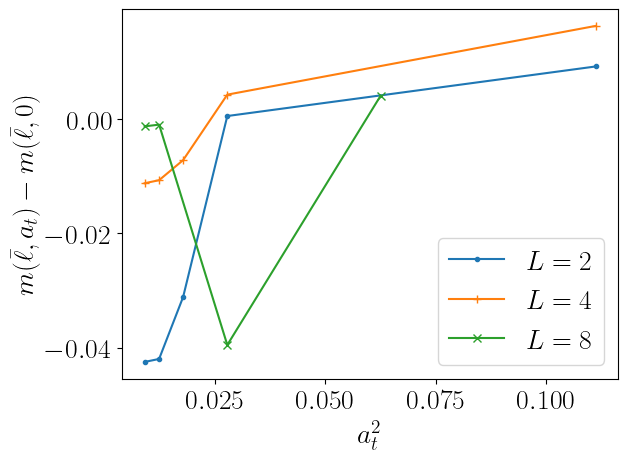

In [161]:
# ibase=0
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='d' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='x' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

In [162]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [163]:
fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

0.9985748056686153